# MeterMind — Cross-Model Comparison




## 0. Imports

In [1]:
import json, io, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from google.colab import files

METRICS  = ['MA', 'SP', 'G']
MODELS   = ['DP Reorderer', 'GRU Attention', 'Claude LLM']
COLOURS  = {'DP Reorderer': 'steelblue', 'GRU Attention': 'seagreen', 'Claude LLM': 'tomato'}
FILES    = {
    'DP Reorderer':  ('dp_reorderer_summary.json',      'dp_reorderer_results.csv'),
    'GRU Attention': ('gru_attention_summary.json',     'gru_attention_results.csv'),
    'Claude LLM':    ('llm_summary.json',               'llm_results.csv'),
}
print('Imports ready.')


Imports ready.


## 1. Load results

Upload the 6 files when prompted: 3 JSONs then 3 CSVs.

In [2]:
print('Upload all 6 files (3 JSON + 3 CSV) when prompted.')
uploaded = files.upload()

summaries = {}   # model -> summary dict
dfs       = {}   # model -> per-line DataFrame

for model, (jf, cf) in FILES.items():
    if jf in uploaded:
        summaries[model] = json.loads(uploaded[jf].decode())
    else:
        print(f'WARNING: {jf} not uploaded — {model} will be skipped.')
    if cf in uploaded:
        dfs[model] = pd.read_csv(io.StringIO(uploaded[cf].decode()))
        dfs[model]['model'] = model
    else:
        print(f'WARNING: {cf} not uploaded — per-line analysis for {model} unavailable.')

# ── Align all models to the same shared input set ────────────────────────────
# Model 1 (DP) ran on the full dataset; models 2 and 3 ran on the test split.
# Filter DP down to only the inputs that appear in both model 2 and model 3
# so all three are compared on identical pairs.
reference_models = [m for m in ['GRU Attention', 'Claude LLM'] if m in dfs]
if reference_models and 'DP Reorderer' in dfs:
    shared_inputs = set(dfs[reference_models[0]]['input'].tolist())
    for m in reference_models[1:]:
        shared_inputs &= set(dfs[m]['input'].tolist())
    original_dp_n = len(dfs['DP Reorderer'])
    dfs['DP Reorderer'] = dfs['DP Reorderer'][
        dfs['DP Reorderer']['input'].isin(shared_inputs)
    ].reset_index(drop=True)
    print(f'DP Reorderer filtered: {original_dp_n} → {len(dfs["DP Reorderer"])} pairs (shared test set)')

# Recompute summaries from CSVs so they reflect the filtered data
for model, df in dfs.items():
    summaries[model] = {
        'model': model,
        'n':     len(df),
        **{m: {'mean': round(float(df[m].mean()), 4),
               'std':  round(float(df[m].std()),  4)}
           for m in METRICS}
    }

# Combined per-line df
all_df = pd.concat(dfs.values(), ignore_index=True) if dfs else pd.DataFrame()

# Summary df
rows = []
for model in MODELS:
    if model not in summaries: continue
    s = summaries[model]
    rows.append({'model': model,
                 **{f'{m}_mean': s[m]['mean'] for m in METRICS},
                 **{f'{m}_std':  s[m]['std']  for m in METRICS}})
summary_df = pd.DataFrame(rows).set_index('model')

print(f'\nAll models aligned to {len(shared_inputs) if reference_models else "?"} shared pairs.')
print(f'Total rows in combined df: {len(all_df)}')
print()
for model in MODELS:
    if model in summaries:
        s = summaries[model]
        print(f"  {model:<18} n={s['n']}  MA={s['MA']['mean']:.3f}  SP={s['SP']['mean']:.3f}  G={s['G']['mean']:.3f}")


Upload all 6 files (3 JSON + 3 CSV) when prompted.


Saving dp_reorderer_results.csv to dp_reorderer_results.csv
Saving dp_reorderer_summary.json to dp_reorderer_summary.json
Saving gru_attention_results.csv to gru_attention_results.csv
Saving gru_attention_summary.json to gru_attention_summary.json
Saving llm_results.csv to llm_results.csv
Saving llm_summary.json to llm_summary.json
DP Reorderer filtered: 1455 → 147 pairs (shared test set)

All models aligned to 147 shared pairs.
Total rows in combined df: 441

  DP Reorderer       n=147  MA=0.999  SP=0.983  G=0.138
  GRU Attention      n=147  MA=0.548  SP=0.262  G=0.097
  Claude LLM         n=147  MA=0.868  SP=0.854  G=0.147


## 2. Headline comparison table

In [3]:
print(f"{'Model':<18} {'MA mean±std':>14} {'SP mean±std':>14} {'G mean±std':>14}")
print('-' * 64)
for model in MODELS:
    if model not in summaries: continue
    s = summaries[model]
    row = '  '.join(f"{s[m]['mean']:.3f}±{s[m]['std']:.3f}" for m in METRICS)
    print(f"{model:<18} {row}")

print()
for m in METRICS:
    winner = max((model for model in summaries), key=lambda x: summaries[x][m]['mean'])
    print(f"  Best {m}: {winner} ({summaries[winner][m]['mean']:.3f})")

Model                 MA mean±std    SP mean±std     G mean±std
----------------------------------------------------------------
DP Reorderer       0.999±0.008  0.983±0.020  0.138±0.017
GRU Attention      0.548±0.263  0.262±0.091  0.097±0.005
Claude LLM         0.868±0.160  0.854±0.102  0.147±0.025

  Best MA: DP Reorderer (0.999)
  Best SP: DP Reorderer (0.983)
  Best G: Claude LLM (0.147)


## 3. Bar chart — mean scores with error bars

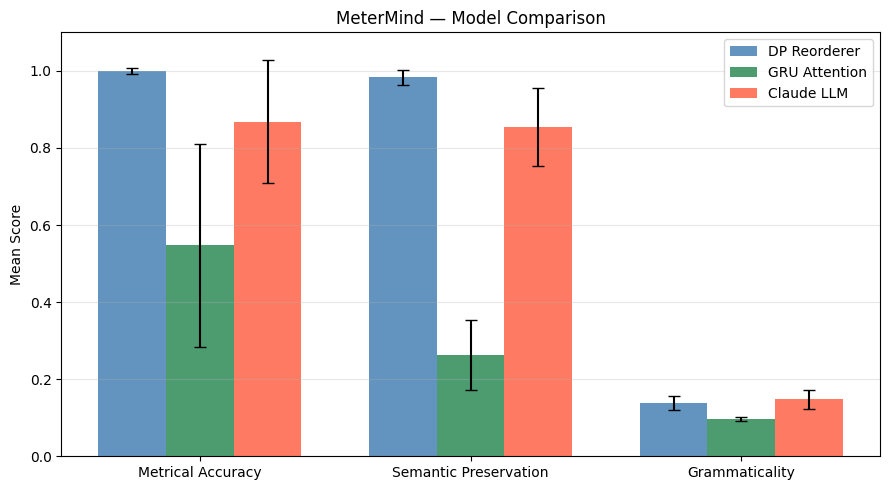

In [4]:
present = [m for m in MODELS if m in summaries]
x       = np.arange(len(METRICS))
width   = 0.25

fig, ax = plt.subplots(figsize=(9, 5))
for k, model in enumerate(present):
    s      = summaries[model]
    means  = [s[m]['mean'] for m in METRICS]
    stds   = [s[m]['std']  for m in METRICS]
    offset = (k - len(present)/2 + 0.5) * width
    ax.bar(x + offset, means, width, yerr=stds, capsize=4,
           label=model, color=COLOURS[model], alpha=0.85, ecolor='black', linewidth=0.5)

ax.set_xticks(x)
ax.set_xticklabels(['Metrical Accuracy', 'Semantic Preservation', 'Grammaticality'])
ax.set_ylabel('Mean Score')
ax.set_ylim(0, 1.1)
ax.set_title('MeterMind — Model Comparison')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('comparison_bar.png', dpi=150)
plt.show()

## 4. Radar chart — model profiles

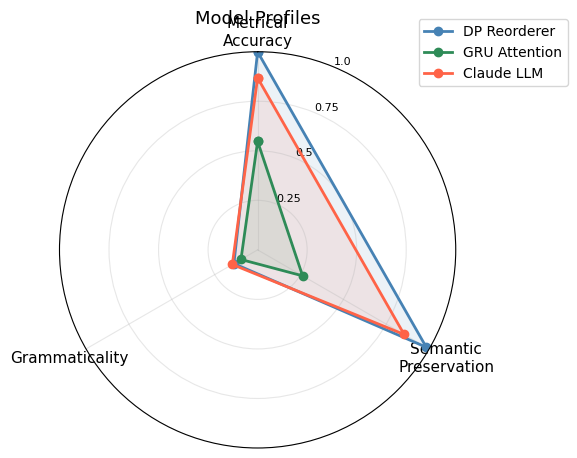

In [5]:
labels  = METRICS
n_axes  = len(labels)
angles  = [2 * math.pi * i / n_axes for i in range(n_axes)]
angles += angles[:1]   # close the polygon

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
ax.set_theta_offset(math.pi / 2)
ax.set_theta_direction(-1)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(['Metrical\nAccuracy', 'Semantic\nPreservation', 'Grammaticality'], size=11)
ax.set_ylim(0, 1)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(['0.25', '0.5', '0.75', '1.0'], size=8)
ax.grid(alpha=0.3)

for model in present:
    values  = [summaries[model][m]['mean'] for m in METRICS]
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, label=model, color=COLOURS[model])
    ax.fill(angles, values, alpha=0.1, color=COLOURS[model])

ax.set_title('Model Profiles', size=13, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.savefig('comparison_radar.png', dpi=150)
plt.show()

## 5. Per-metric distributions

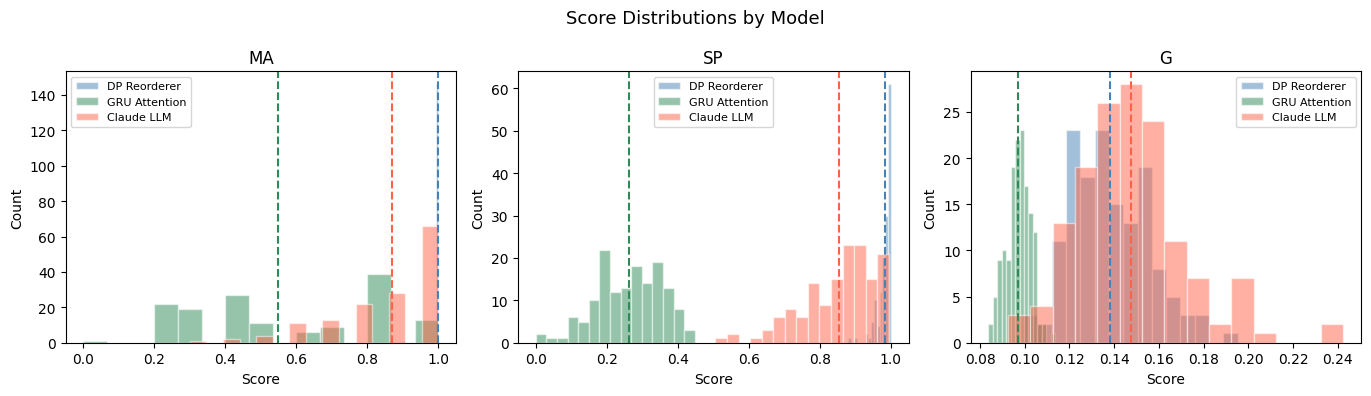

In [6]:
if not all_df.empty:
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    fig.suptitle('Score Distributions by Model', fontsize=13)
    for ax, metric in zip(axes, METRICS):
        for model in present:
            if model not in dfs: continue
            vals = dfs[model][metric].dropna()
            ax.hist(vals, bins=15, alpha=0.5, label=model,
                    color=COLOURS[model], edgecolor='white')
            ax.axvline(vals.mean(), color=COLOURS[model],
                       linestyle='--', linewidth=1.5)
        ax.set_title(metric)
        ax.set_xlabel('Score')
        ax.set_ylabel('Count')
        ax.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig('comparison_distributions.png', dpi=150)
    plt.show()

## 6. Error analysis — where each model fails

Bottom 10 lines by MA per model. How much overlap is there — do models fail on the same inputs?

In [7]:
if not all_df.empty:
    print('=== Bottom 10 lines by MA per model ===')
    worst_inputs = {}
    for model in present:
        if model not in dfs: continue
        worst = dfs[model].nsmallest(10, 'MA')
        worst_inputs[model] = set(worst['input'].tolist())
        print(f'\n{model}:')
        for _, row in worst.iterrows():
            print(f"  MA={row['MA']:.3f}  {row['input'][:60]}")

    # Overlap
    print('\n=== Failure overlap (shared worst inputs) ===')
    models_with_data = [m for m in present if m in worst_inputs]
    for i, m1 in enumerate(models_with_data):
        for m2 in models_with_data[i+1:]:
            shared = worst_inputs[m1] & worst_inputs[m2]
            print(f"  {m1} ∩ {m2}: {len(shared)} shared failures")
            for s in shared:
                print(f"    {s[:70]}")

=== Bottom 10 lines by MA per model ===

DP Reorderer:
  MA=0.900  To stop posterity, his self-love—of what consequence is it?
  MA=1.000  Of his self-love doth he wish to stop posterity?
  MA=1.000  His self-love, whereby he doth of posterity seek to stop the
  MA=1.000  Despite the wrinkles that doth mar thy countenance, this gol
  MA=1.000  This golden time of thine shall endure, despite of all the w
  MA=1.000  Despise not the wrinkles that come upon thee, for this thy g
  MA=1.000  Make sweet some vial, and treasure thou some place most dear
  MA=1.000  Thou shalt make sweet some vial, and treasure it within some
  MA=1.000  Make some vial sweet, I prithee, and let treasure be kept in
  MA=1.000  Make thee another self, I do beseech thee, for the love of m

GRU Attention:
  MA=0.000  Thou, who art best among the dearest of my heart, art mine o
  MA=0.200  Which did erst canopy the herd from heat, as a protective sh
  MA=0.200  And for true things deemed worthy, to truths translate

## 7. DP unchanged output analysis

How often does the DP reorderer return the input unchanged? Do those lines score differently?

In [8]:
if 'DP Reorderer' in dfs:
    dp = dfs['DP Reorderer'].copy()
    # Normalise both sides for comparison
    dp['input_clean']  = dp['input'].str.lower().str.replace(r'[^a-z\s]', '', regex=True).str.strip()
    dp['output_clean'] = dp['output'].str.lower().str.replace(r'[^a-z\s]', '', regex=True).str.strip()
    dp['unchanged']    = dp['input_clean'] == dp['output_clean']

    n_unchanged = dp['unchanged'].sum()
    print(f'DP unchanged outputs: {n_unchanged} / {len(dp)} ({100*n_unchanged/len(dp):.1f}%)')
    print()

    for group, label in [(True, 'Unchanged'), (False, 'Reordered')]:
        subset = dp[dp['unchanged'] == group]
        if len(subset) == 0: continue
        print(f'{label} (n={len(subset)}):')
        for m in METRICS:
            print(f"  {m}: {subset[m].mean():.3f} ± {subset[m].std():.3f}")
        print()

DP unchanged outputs: 37 / 147 (25.2%)

Unchanged (n=37):
  MA: 1.000 ± 0.000
  SP: 1.000 ± 0.000
  G: 0.152 ± 0.018

Reordered (n=110):
  MA: 0.999 ± 0.010
  SP: 0.978 ± 0.020
  G: 0.134 ± 0.015



## 8. Claude word constraint analysis

For each Claude output, count words added that weren't in the input. Does violating the constraint correlate with better or worse MA?

Claude outputs with word violations: 93 / 147 (63.3%)
Mean violations per output: 1.66

Compliant (no new words) (n=54):
  MA: 0.835 ± 0.180
  SP: 0.877 ± 0.091
  G: 0.146 ± 0.025

Violations (added words) (n=93):
  MA: 0.887 ± 0.145
  SP: 0.841 ± 0.106
  G: 0.148 ± 0.024



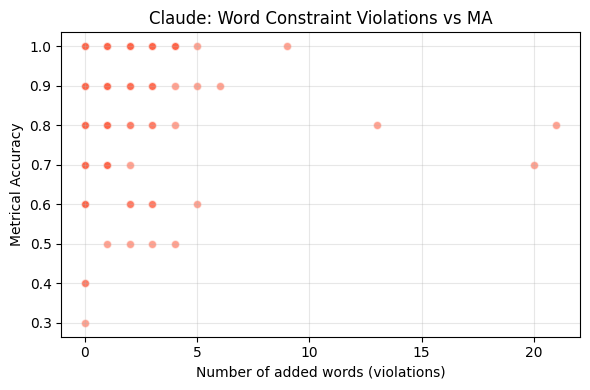

In [9]:
if 'Claude LLM' in dfs:
    cl = dfs['Claude LLM'].copy()

    def violation_count(row):
        import re
        clean = lambda s: set(re.sub(r"[^a-z\s]", "", s.lower()).split())
        return len(clean(row['output']) - clean(row['input']))

    cl['violations'] = cl.apply(violation_count, axis=1)
    n_viol = (cl['violations'] > 0).sum()
    print(f'Claude outputs with word violations: {n_viol} / {len(cl)} ({100*n_viol/len(cl):.1f}%)')
    print(f'Mean violations per output: {cl["violations"].mean():.2f}')
    print()

    # Compliant vs violating
    for group, label in [(0, 'Compliant (no new words)'), (None, 'Violations (added words)')]:
        subset = cl[cl['violations'] == 0] if group == 0 else cl[cl['violations'] > 0]
        if len(subset) == 0: continue
        print(f'{label} (n={len(subset)}):')
        for m in METRICS:
            print(f"  {m}: {subset[m].mean():.3f} ± {subset[m].std():.3f}")
        print()

    # Scatter: violations vs MA
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.scatter(cl['violations'], cl['MA'], alpha=0.6, color=COLOURS['Claude LLM'], edgecolors='white')
    ax.set_xlabel('Number of added words (violations)')
    ax.set_ylabel('Metrical Accuracy')
    ax.set_title('Claude: Word Constraint Violations vs MA')
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('claude_violations.png', dpi=150)
    plt.show()

## 9. SP vs MA scatter — quality–fluency tradeoff

Does improving metrical accuracy come at the cost of semantic preservation?

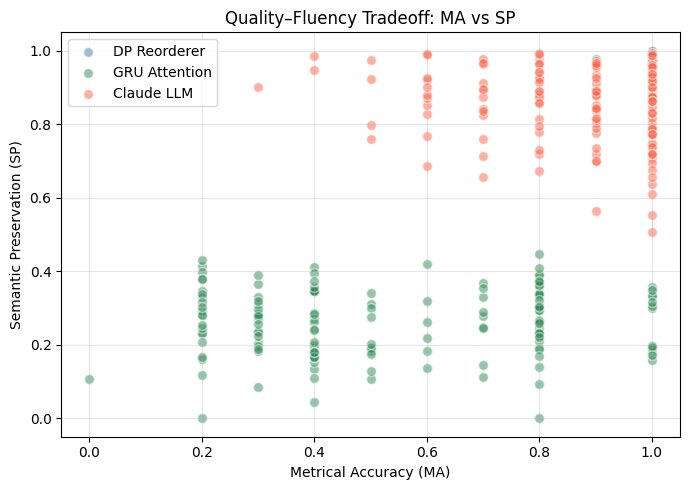

MA–SP correlation per model:
  DP Reorderer: r=0.024
  GRU Attention: r=0.082
  Claude LLM: r=-0.153


In [10]:
if not all_df.empty:
    fig, ax = plt.subplots(figsize=(7, 5))
    for model in present:
        if model not in dfs: continue
        d = dfs[model]
        ax.scatter(d['MA'], d['SP'], alpha=0.5, label=model,
                   color=COLOURS[model], edgecolors='white', s=50)
    ax.set_xlabel('Metrical Accuracy (MA)')
    ax.set_ylabel('Semantic Preservation (SP)')
    ax.set_title('Quality–Fluency Tradeoff: MA vs SP')
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('comparison_scatter.png', dpi=150)
    plt.show()

    # Correlation per model
    print('MA–SP correlation per model:')
    for model in present:
        if model not in dfs: continue
        r = dfs[model][['MA', 'SP']].corr().iloc[0, 1]
        print(f'  {model}: r={r:.3f}')

## 10. Save comparison summary

In [12]:
# Combined summary JSON
comparison_summary = {'models': summaries}
with open('comparison_summary.json', 'w') as f:
    json.dump(comparison_summary, f, indent=2)
print('Saved comparison_summary.json')

# Combined per-line CSV
if not all_df.empty:
    all_df.to_csv('comparison_all_lines.csv', index=False)
    print('Saved comparison_all_lines.csv')

# Download everything
for fname in ['comparison_summary.json', 'comparison_all_lines.csv',
              'comparison_bar.png', 'comparison_radar.png',
              'comparison_distributions.png', 'comparison_scatter.png',
              'claude_violations.png']:
    try:
        files.download(fname)
    except Exception:
        pass
print('Done.')

Saved comparison_summary.json
Saved comparison_all_lines.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Done.
